MSE states that Least Linear Squares is the best method
RS states that Polynomial Fit is the best method
Slope: -0.10862651912933692, Intercept: 0.6502381919050588


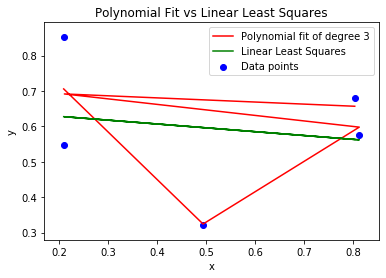

In [41]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
x = rng.random(5)
y = rng.random(5)

A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
lls_y=m*x+c

mse_lls = np.mean((y - lls_y)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - lls_y)**2)
r_lls = 1 - (ss_res / ss_total)

degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

mse_pf = np.mean((y - y_pred)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_pf = 1 - (ss_res / ss_total)

if mse_lls > mse_pf:
    print('MSE states that Least Linear Squares is the best method')
else:
    print('MSE states that Polynomial Fit is the best method')
    
if r_lls > r_pf:
    print('RS states that Least Linear Squares is the best method')
else:
    print('RS states that Polynomial Fit is the best method')

plt.scatter(x, y, color='blue', label='Data points') 
plt.plot(x, y_pred, color='red', label=f'Polynomial fit of degree {degree}')
plt.title('Polynomial Fit vs Linear Least Squares')
plt.xlabel('x')
plt.ylabel('y')

print(f"Slope: {m}, Intercept: {c}")
plt.plot(x, m*x +c, color='green', label=f'Linear Least Squares')
plt.legend()
plt.show()

In [45]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng()
x = rng.random(10)
y = rng.random(10)

A = np.vstack([x, np.ones(len(x))]).T
m, c = np.linalg.lstsq(A, y, rcond=None)[0]
lls_y=m*x+c

mse_lls = np.mean((y - lls_y)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - lls_y)**2)
r_lls = 1 - (ss_res / ss_total)

degree = 3
coefficients = np.polyfit(x, y, degree)
polynomial = np.poly1d(coefficients)
y_pred = polynomial(x)

mse_pf = np.mean((y - y_pred)**2)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_pf = 1 - (ss_res / ss_total)

deg_max = len(x) + 1
results = []
r_cubic = r_pf

print('       Results with degrees cranked up:')
for degree in range(3, deg_max + 1):
    coeff = np.polyfit(x, y, degree)
    poly = np.poly1d(coeff)
    y_pred1 = poly(x)
    mse_pf1 = np.mean((y - y_pred1)**2)

    ss_res1 = np.sum((y - y_pred1)**2)
    r_pf1 = 1 - (ss_res1 / ss_total)
    
    if(r_pf1 == 1):
        print('The degree is overfitting')
        break
    
    results.append((degree,mse_pf1,r_pf1))
    print('Degree: ',degree,' MSE: ',mse_pf1, ' RS: ',r_pf1)
    
print('       Results with degrees cranked down:')
for degree in range(2, 0, -1):
    coefficients = np.polyfit(x, y, degree)
    polynomial = np.poly1d(coefficients)
    y_pred = polynomial(x)
    mse_pf2 = np.mean((y - y_pred)**2)

    ss_res2 = np.sum((y - y_pred)**2)
    r_pf2 = 1 - (ss_res2 / ss_total)
    
    if(r_pf2 < 0.95*r_cubic):
        print('The degree is underfitting')
        break

       Results with degrees cranked up:
Degree:  3  MSE:  0.07890103479343025  RS:  0.11129676536937949
Degree:  4  MSE:  0.061032695196024014  RS:  0.3125571320967314
Degree:  5  MSE:  0.05286070570743447  RS:  0.4046024837311014
Degree:  6  MSE:  0.04203948035465337  RS:  0.5264875515107725
Degree:  7  MSE:  0.032394024625671494  RS:  0.6351293168345702
Degree:  8  MSE:  0.009986490981628546  RS:  0.8875169779304112
Degree:  9  MSE:  1.9350762645055028e-16  RS:  0.9999999999999978
Degree:  10  MSE:  1.0397398289344924e-17  RS:  0.9999999999999999
Degree:  11  MSE:  9.777737097066723e-18  RS:  0.9999999999999999
       Results with degrees cranked down:
The degree is underfitting


/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
/opt/conda/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3326: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)
